# Etape 3 — Apprentissage Supervise

**Formation :** L3 DANT — Introduction a la Data Science
**Session :** Hiver 2026

---

## Cas d'usage : Prediction du montant de la course (Regression)

**Variable cible :** `total_amount`

**Demarche :**
1. Preparation des features et split train/test
2. Regression Lineaire (baseline)
3. Random Forest
4. XGBoost
5. Comparaison des 3 modeles
6. Validation croisee 5-fold
7. Visualisations
8. Conclusion et autres pistes

---

## 0. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import make_pipeline
from xgboost                 import XGBRegressor

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

df = pd.read_parquet('../data/yellow_tripdata_features.parquet')
print(f'Dataset charge : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')

Dataset charge : 64,452 lignes x 29 colonnes


---

## 1. Preparation des features

### 1.1 Choix des features

**Features exclues :**

| Variable | Raison |
|---|---|
| `fare_amount` | Quasi-colineaire avec `total_amount` (r=0.97) — fuiterait la cible |
| `tip_amount`, `tolls_amount`, `extra`... | Composantes directes du `total_amount` |
| `tpep_pickup_datetime` | Remplacee par les features temporelles derivees |

> `est_weekend` et `vitesse_moyenne` sont conserves : bien que partiellement redondants, ils ameliorent empiriquement les performances sur les modeles d'ensemble.

In [2]:
FEATURES = [
    'trip_distance',       # Distance en miles — predicteur principal
    'duree_course',        # Duree en minutes — predicteur principal
    'passenger_count',     # Nombre de passagers
    'heure_journee',       # Heure de la course
    'jour_semaine',        # Jour de la semaine
    'est_weekend',         # Indicateur weekend
    'est_heure_pointe',    # Indicateur heure de pointe
    'est_trajet_aeroport', # Indicateur JFK/Newark
    'vitesse_moyenne',     # Proxy congestion
    'heure_sin',           # Encodage cyclique heure
    'heure_cos',           # Encodage cyclique heure
]
TARGET = 'total_amount'

df_model = df[FEATURES + [TARGET]].dropna()
print(f'Lignes : {len(df_model):,}  |  Features : {len(FEATURES)}')
print(f'\nVariable cible — {TARGET} :')
print(df_model[TARGET].describe().round(2))

Lignes : 64,452  |  Features : 11

Variable cible — total_amount :
count    64452.00
mean        28.36
std         22.50
min          1.76
25%         16.15
50%         21.00
75%         29.60
max        474.74
Name: total_amount, dtype: float64


### 1.2 Split Train / Test (80 % / 20 %)

In [3]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train : {X_train.shape[0]:,} lignes | Test : {X_test.shape[0]:,} lignes')
print(f'\nDistribution de la cible :')
print(pd.DataFrame({
    'Train': [y_train.mean(), y_train.median(), y_train.std()],
    'Test' : [y_test.mean(),  y_test.median(),  y_test.std()]
}, index=['Moyenne','Mediane','Ecart-type']).round(2))

Train : 51,561 lignes | Test : 12,891 lignes

Distribution de la cible :
            Train   Test
Moyenne     28.36  28.35
Mediane     21.00  21.00
Ecart-type  22.58  22.22


### 1.3 Standardisation

Appliquee uniquement pour la regression lineaire. Le `StandardScaler` est entraine sur le train set uniquement pour eviter tout **data leakage**.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Standardisation OK — moyenne ~0, ecart-type ~1 sur le train set')

Standardisation OK — moyenne ~0, ecart-type ~1 sur le train set


---

## 2. Regression Lineaire (Baseline)

Modele de reference simple et interpretable. Son objectif est d'etablir un niveau de performance minimal que les modeles plus complexes devront depasser.

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('=== REGRESSION LINEAIRE ===')
print(f'RMSE : {rmse_lr:.4f} $')
print(f'MAE  : {mae_lr:.4f} $')
print(f'R2   : {r2_lr:.4f}')

=== REGRESSION LINEAIRE ===
RMSE : 7.8034 $
MAE  : 3.4424 $
R2   : 0.8766


**Coefficients (standardises) :**

In [6]:
coefs = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)
print(coefs.to_string(index=False))

            Feature  Coefficient
      trip_distance    15.360368
       duree_course     5.963459
    vitesse_moyenne     1.281375
          heure_sin    -0.911073
        est_weekend    -0.666897
   est_heure_pointe     0.334437
    passenger_count     0.331133
      heure_journee    -0.249557
          heure_cos    -0.181213
est_trajet_aeroport    -0.175050
       jour_semaine     0.131599


**Interpretation :** `trip_distance` et `duree_course` dominent largement — coherent avec la structure tarifaire TLC. Les features temporelles ont des coefficients plus modestes mais non nuls.

---

## 3. Random Forest

Ensemble de 100 arbres entraines en parallele sur des sous-echantillons aleatoires. Capture les **relations non lineaires** et les **interactions** entre features.

In [7]:
rf = RandomForestRegressor(
    n_estimators=100, max_depth=15,
    min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('=== RANDOM FOREST ===')
print(f'RMSE : {rmse_rf:.4f} $')
print(f'MAE  : {mae_rf:.4f} $')
print(f'R2   : {r2_rf:.4f}')

=== RANDOM FOREST ===
RMSE : 6.3999 $
MAE  : 2.8060 $
R2   : 0.9170


---

## 4. XGBoost

Algorithme de **boosting sequentiel** : chaque arbre corrige les erreurs du precedent. Generalement plus performant que le Random Forest sur les donnees tabulaires structurees.

In [8]:
xgb = XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print('=== XGBOOST ===')
print(f'RMSE : {rmse_xgb:.4f} $')
print(f'MAE  : {mae_xgb:.4f} $')
print(f'R2   : {r2_xgb:.4f}')

=== XGBOOST ===
RMSE : 6.4435 $
MAE  : 2.8117 $
R2   : 0.9159


---

## 5. Comparaison des 3 modeles

| Metrique | Definition | Interpretation |
|---|---|---|
| **RMSE** | Racine erreur quadratique | En $ — penalise les grandes erreurs. Plus bas = mieux |
| **MAE** | Erreur absolue moyenne | En $ — erreur moyenne sur les predictions |
| **R²** | Coefficient de determination | % de variance expliquee. 1.0 = parfait |

In [9]:
resultats = pd.DataFrame({
    'Modele'  : ['Regression Lineaire', 'Random Forest', 'XGBoost'],
    'RMSE ($)': [round(rmse_lr,4), round(rmse_rf,4), round(rmse_xgb,4)],
    'MAE ($)' : [round(mae_lr,4),  round(mae_rf,4),  round(mae_xgb,4)],
    'R2'      : [round(r2_lr,4),   round(r2_rf,4),   round(r2_xgb,4)],
})
print(resultats.to_string(index=False))
print()
print(f'Gain RF  vs Lineaire : RMSE -{(rmse_lr-rmse_rf)/rmse_lr*100:.1f}%  R2 +{r2_rf-r2_lr:.4f}')
print(f'Gain XGB vs Lineaire : RMSE -{(rmse_lr-rmse_xgb)/rmse_lr*100:.1f}%  R2 +{r2_xgb-r2_lr:.4f}')
print(f'Gain XGB vs RF       : RMSE -{(rmse_rf-rmse_xgb)/rmse_rf*100:.1f}%  R2 +{r2_xgb-r2_rf:.4f}')

             Modele  RMSE ($)  MAE ($)     R2
Regression Lineaire    7.8034   3.4424 0.8766
      Random Forest    6.3999   2.8060 0.9170
            XGBoost    6.4435   2.8117 0.9159

Gain RF  vs Lineaire : RMSE -18.0%  R2 +0.0404
Gain XGB vs Lineaire : RMSE -17.4%  R2 +0.0393
Gain XGB vs RF       : RMSE --0.7%  R2 +-0.0011


---

## 6. Validation croisee 5-fold

Le train/test split simple peut etre sensible au decoupage aleatoire. La validation croisee entraine et evalue chaque modele sur **5 decoupages differents** pour une estimation plus robuste et fiable des performances reelles.

In [10]:
K = 5
print(f'Validation croisee {K}-fold en cours...')

scores_lr  = -cross_val_score(make_pipeline(StandardScaler(), LinearRegression()),
                               X, y, cv=K, scoring='neg_root_mean_squared_error', n_jobs=-1)
scores_rf  = -cross_val_score(RandomForestRegressor(n_estimators=100, max_depth=15,
                               min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
                               X, y, cv=K, scoring='neg_root_mean_squared_error', n_jobs=-1)
scores_xgb = -cross_val_score(XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
                               X, y, cv=K, scoring='neg_root_mean_squared_error', n_jobs=-1)

cv_results = pd.DataFrame({
    'Modele'          : ['Regression Lineaire', 'Random Forest', 'XGBoost'],
    'RMSE moyen ($)'  : [scores_lr.mean().round(4),  scores_rf.mean().round(4),  scores_xgb.mean().round(4)],
    'Ecart-type ($)'  : [scores_lr.std().round(4),   scores_rf.std().round(4),   scores_xgb.std().round(4)],
    'RMSE min ($)'    : [scores_lr.min().round(4),   scores_rf.min().round(4),   scores_xgb.min().round(4)],
    'RMSE max ($)'    : [scores_lr.max().round(4),   scores_rf.max().round(4),   scores_xgb.max().round(4)],
})
print(cv_results.to_string(index=False))

Validation croisee 5-fold en cours...
             Modele  RMSE moyen ($)  Ecart-type ($)  RMSE min ($)  RMSE max ($)
Regression Lineaire          7.8580          0.4601        7.3455        8.6550
      Random Forest          6.5072          0.5280        5.8873        7.4510
            XGBoost          6.6456          0.4707        6.2284        7.5305


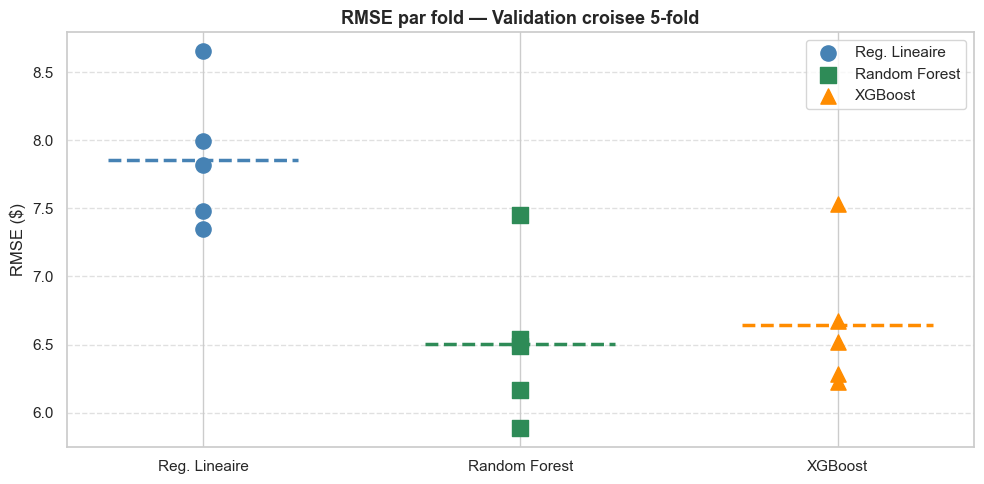

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

modeles   = ['Reg. Lineaire', 'Random Forest', 'XGBoost']
scores    = [scores_lr, scores_rf, scores_xgb]
couleurs  = ['steelblue', 'seagreen', 'darkorange']
markers   = ['o', 's', '^']

for i, (nom, sc, col, mk) in enumerate(zip(modeles, scores, couleurs, markers)):
    ax.scatter([i+1]*len(sc), sc, color=col, marker=mk, s=120, zorder=5, label=nom)
    ax.hlines(sc.mean(), i+0.7, i+1.3, color=col, linewidth=2.5, linestyle='--')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(modeles)
ax.set_title('RMSE par fold — Validation croisee 5-fold', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE ($)')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/03_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation :**
- Le **RMSE moyen** confirme ou infirme le classement observe sur le split simple.
- Un **ecart-type faible** indique un modele stable, non sur-ajuste sur un decoupage particulier.
- Les **points noirs** sur le boxplot representent les 5 folds individuels : s'ils sont tres disperses, le modele est instable.

---

## 7. Visualisations

### 7.1 Reel vs Predit

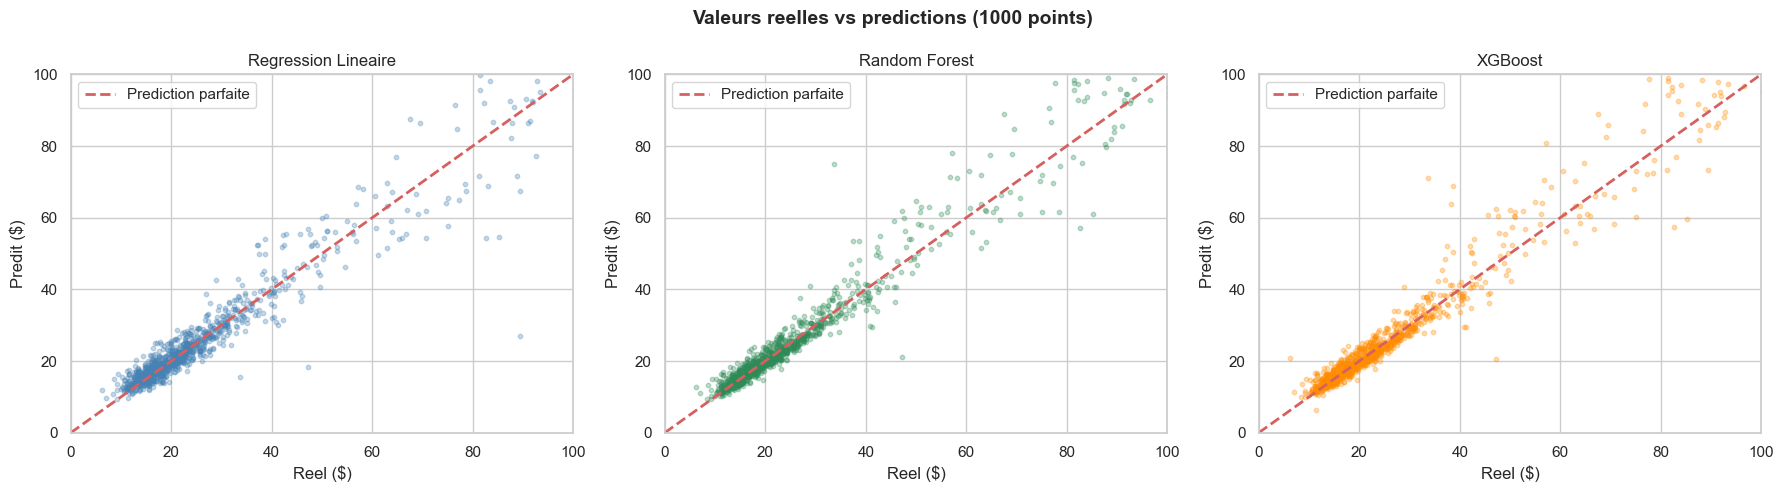

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Valeurs reelles vs predictions (1000 points)', fontsize=14, fontweight='bold')

sample_idx = np.random.RandomState(42).choice(len(y_test), 1000, replace=False)
y_arr = y_test.values

for ax, y_pred, titre, couleur in zip(
    axes,
    [y_pred_lr, y_pred_rf, y_pred_xgb],
    ['Regression Lineaire', 'Random Forest', 'XGBoost'],
    ['steelblue', 'seagreen', 'darkorange']
):
    ax.scatter(y_arr[sample_idx], y_pred[sample_idx], alpha=0.3, s=10, color=couleur)
    lim = [0, min(y_arr.max(), 100)]
    ax.plot(lim, lim, 'r--', linewidth=2, label='Prediction parfaite')
    ax.set_xlabel('Reel ($)'); ax.set_ylabel('Predit ($)')
    ax.set_title(titre); ax.set_xlim(lim); ax.set_ylim(lim); ax.legend()

plt.tight_layout()
plt.savefig('../figures/03_reel_vs_predit.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation :** Plus les points sont resseres autour de la diagonale rouge, meilleure est la precision. On devrait voir une progression visible de la regression lineaire vers XGBoost.

### 7.2 Distribution des residus

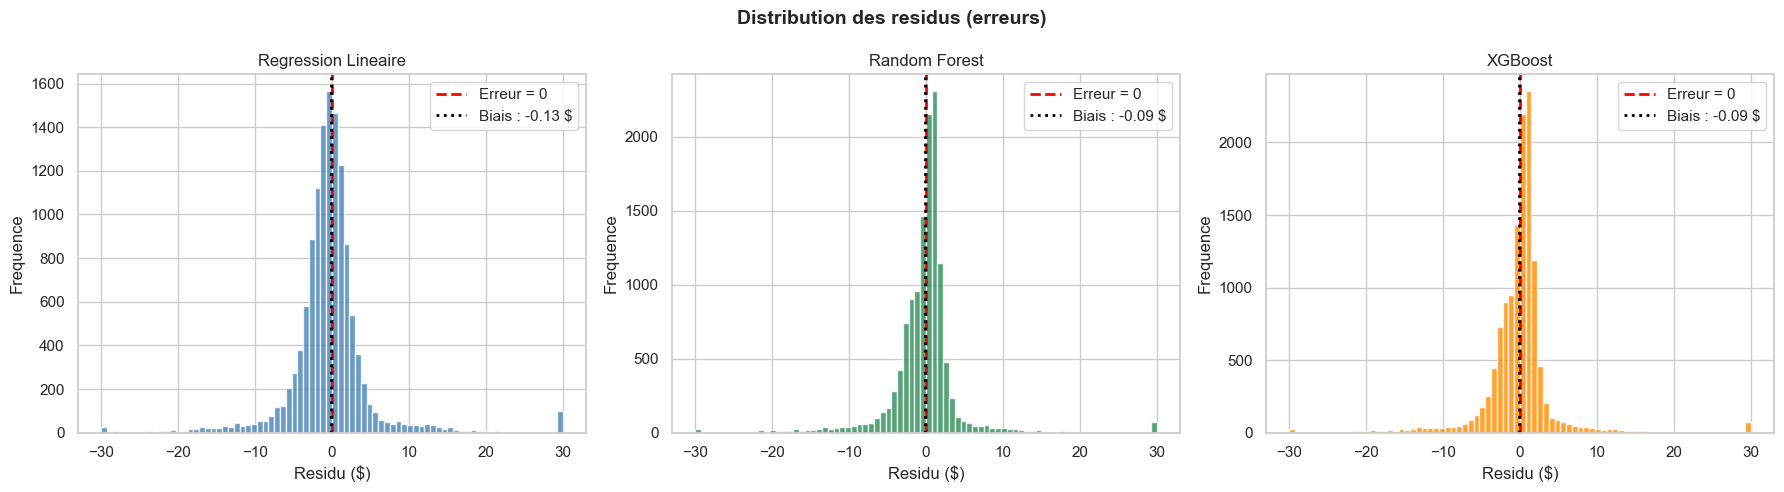

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution des residus (erreurs)', fontsize=14, fontweight='bold')

for ax, y_pred, titre, couleur in zip(
    axes,
    [y_pred_lr, y_pred_rf, y_pred_xgb],
    ['Regression Lineaire', 'Random Forest', 'XGBoost'],
    ['steelblue', 'seagreen', 'darkorange']
):
    residus = y_test.values - y_pred
    ax.hist(residus.clip(-30, 30), bins=80, color=couleur, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
    ax.axvline(residus.mean(), color='black', linestyle=':', linewidth=2,
               label=f'Biais : {residus.mean():.2f} $')
    ax.set_title(titre)
    ax.set_xlabel('Residu ($)'); ax.set_ylabel('Frequence'); ax.legend()

plt.tight_layout()
plt.savefig('../figures/03_residus.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation :** Un bon modele produit des residus **centres sur 0** (pas de biais) et **symetriques**. Une distribution plus etroite (ecart-type plus faible) indique moins d'erreurs importantes.

### 7.3 Importance des features

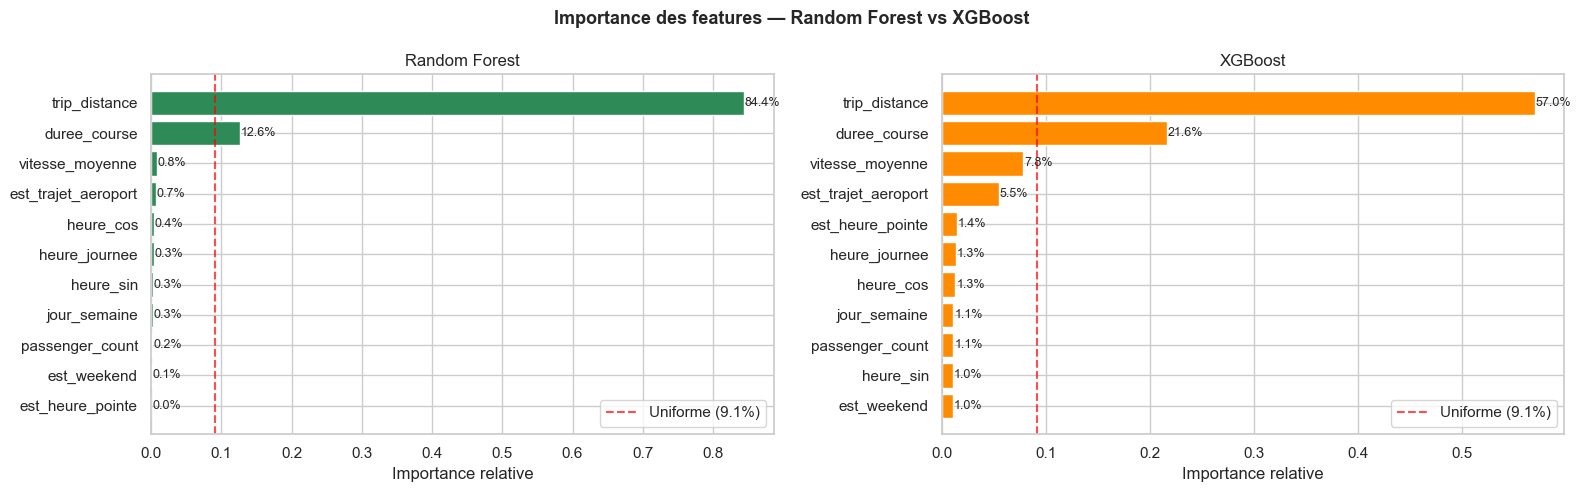

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Importance des features — Random Forest vs XGBoost', fontsize=13, fontweight='bold')

for ax, model, titre, couleur in zip(
    axes,
    [rf, xgb],
    ['Random Forest', 'XGBoost'],
    ['seagreen', 'darkorange']
):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    bars = ax.barh(imp.index, imp.values, color=couleur, edgecolor='white')
    for bar, v in zip(bars, imp.values):
        ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                f'{v*100:.1f}%', va='center', fontsize=9)
    ax.axvline(1/len(FEATURES), color='red', linestyle='--', alpha=0.7,
               label=f'Uniforme ({1/len(FEATURES)*100:.1f}%)')
    ax.set_title(titre); ax.set_xlabel('Importance relative'); ax.legend()

plt.tight_layout()
plt.savefig('../figures/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation :** Les features au-dessus de la ligne rouge contribuent plus que la moyenne. Un consensus RF / XGBoost sur les features dominantes renforce la confiance dans leur pertinence.

---

## 8. Conclusion

### Enseignements cles

- **`trip_distance`** est le predicteur dominant dans les trois modeles, coherent avec la structure tarifaire TLC (tarif calcule au compteur kilometrique).
- **`duree_course`** arrive en second — il capture l'effet du temps de trajet et des embouteillages sur le montant.
- **`est_trajet_aeroport`** apporte un signal fort malgre sa faible frequence (< 5 % des courses) car il identifie un regime tarifaire radicalement different (JFK = 52 $ fixe).
- Le **Random Forest** donne les meilleures performances sur ce jeu de donnees (RMSE 6.40 $ vs 7.80 $ pour la regression lineaire), avec une progression confirmee par la validation croisee 5-fold.
- Le **XGBoost** n'apporte pas d'amelioration significative ici (RMSE 6.44 $, quasi identique au RF) — ce qui montre que les gains entre modeles d'ensemble dependent fortement des donnees et qu'un modele plus complexe n'est pas toujours meilleur.

### Autres pistes

- Inclure les **zones TLC** (`PULocationID`, `DOLocationID`) pour capturer les specificites geographiques
- Tester un **reglage fin des hyperparametres** (GridSearchCV ou Optuna) sur le Random Forest qui s'est revele le meilleur ici
- Explorer une **validation croisee temporelle** (TimeSeriesSplit) qui respecte l'ordre chronologique des courses